In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import requests

# ── Paths ─────────────────────────────────────────────────────────────────────
GRID_PARQUET_PATH  = "../outputs/grid_assigned.parquet"
GRID_GPKG_PATH     = "../outputs/denmark_grid.gpkg"
ADMIN_GPKG_PATH    = "../outputs/denmark_admin.gpkg"   # for the boundary overlay
NATPARKS_SAVE_PATH = "../outputs/denmark_national_parks.gpkg"

In [10]:
# Load the downloaded GeoJSON
raw = gpd.read_file("export.geojson").to_crs(epsg=4326)

print(f"Features in file : {len(raw)}")
print(f"Columns          : {raw.columns.tolist()}")

# Inspect what names came through
print(raw[["name"]].to_string())

Features in file : 14
Columns          : ['id', '@id', 'boundary', 'communication:amateur_radio:pota', 'fixme', 'image', 'leaf_cycle', 'leisure', 'lst:beskrivning', 'lst:reviderad', 'lst:tillkomst', 'name', 'name:da', 'name:de', 'name:en', 'name:frr', 'name:nl', 'natura2000_release', 'natura2000_sitecode', 'natura2000_sitetype', 'natural', 'note:de', 'protect_class', 'protection_title', 'related_law', 'related_law:url', 'short_protection_title', 'source', 'source:protect_class', 'type', 'website', 'wikidata', 'wikipedia', 'geometry']
                                                name
0                               Nationalpark Jasmund
1                           Stenshuvuds nationalpark
2        Nationalpark Vorpommersche Boddenlandschaft
3   Nationalpark Schleswig-Holsteinisches Wattenmeer
4                                        Store Mosse
5                                   Nationalpark Thy
6                           Nationalpark Mols Bjerge
7                                   

In [11]:
# The 5 official Danish national parks — filter to exactly these
DANISH_NATIONAL_PARKS = [
    "Nationalpark Thy",
    "Nationalpark Mols Bjerge",
    "Nationalpark Vadehavet",
    "Nationalpark Skjoldungernes Land",
    "Nationalpark Kongernes Nordsjælland"
]

national_parks = raw[raw["name"].isin(DANISH_NATIONAL_PARKS)].copy()

# Verify
print(f"Parks kept : {len(national_parks)}")
print(national_parks[["name"]].to_string())

# Save for reuse — you never need to re-download
national_parks.to_file(NATPARKS_SAVE_PATH, driver="GPKG")
print(f"Saved to {NATPARKS_SAVE_PATH}")

Parks kept : 5
                                   name
5                      Nationalpark Thy
6              Nationalpark Mols Bjerge
9      Nationalpark Skjoldungernes Land
10               Nationalpark Vadehavet
11  Nationalpark Kongernes Nordsjælland
Saved to ../outputs/denmark_national_parks.gpkg


In [12]:
# ── Load data ─────────────────────────────────────────────────────────────────
df = pd.read_parquet(GRID_PARQUET_PATH)
df = df.dropna(subset=["decimalLatitude", "decimalLongitude"])

print(f"Records loaded  : {len(df):,}")
print(f"Unique species  : {df['species'].nunique():,}")

Records loaded  : 30,138,961
Unique species  : 510


In [13]:
# ── Compute species richness per grid cell ────────────────────────────────────
richness = (
    df.groupby("grid_cell_id")["species"]
    .nunique()
    .reset_index()
    .rename(columns={"species": "species_richness"})
)

print(f"Total grid cells with records: {len(richness):,}")
print(f"\nRichness distribution:")
print(richness["species_richness"].describe())

Total grid cells with records: 134

Richness distribution:
count    134.000000
mean     256.111940
std       49.581657
min       16.000000
25%      237.000000
50%      260.500000
75%      285.000000
max      374.000000
Name: species_richness, dtype: float64


In [14]:
# ── Define hotspot threshold ───────────────────────────────────────────────────
TOTAL_SPECIES    = 510
HOTSPOT_FRACTION = 0.60
HOTSPOT_THRESHOLD = TOTAL_SPECIES * HOTSPOT_FRACTION  # = 306

# Any cell with species_richness >= 306 is a hotspot
hotspots    = richness[richness["species_richness"] >= HOTSPOT_THRESHOLD]
non_hotspot = richness[richness["species_richness"] <  HOTSPOT_THRESHOLD]

print(f"Total unique species          : {TOTAL_SPECIES}")
print(f"Hotspot threshold (60%)       : {HOTSPOT_THRESHOLD:.1f} → cells with ≥ 306 species")
print(f"Hotspot cells                 : {len(hotspots):,}")
print(f"Non-hotspot cells with records: {len(non_hotspot):,}")
print(f"\nHotspot richness range: "
      f"{hotspots['species_richness'].min()} – {hotspots['species_richness'].max()}")

Total unique species          : 510
Hotspot threshold (60%)       : 306.0 → cells with ≥ 306 species
Hotspot cells                 : 14
Non-hotspot cells with records: 120

Hotspot richness range: 309 – 374


In [15]:
# ── Load grid geometry and merge richness ─────────────────────────────────────
grid_gdf = gpd.read_file(GRID_GPKG_PATH)

# Merge richness values onto grid geometry
grid_richness = grid_gdf.merge(richness, on="grid_cell_id", how="left")
grid_richness["species_richness"] = grid_richness["species_richness"].fillna(0)

# Create a boolean hotspot flag column for easy filtering
grid_richness["is_hotspot"] = grid_richness["species_richness"] >= HOTSPOT_THRESHOLD

print(f"Grid cells in GeoPackage : {len(grid_gdf):,}")
print(f"Hotspot cells in grid    : {grid_richness['is_hotspot'].sum():,}")

Grid cells in GeoPackage : 134
Hotspot cells in grid    : 14


In [16]:
# ── Load Denmark and national park outlines ──────────────────────────────────────────────────────
denmark_outline = gpd.read_file(ADMIN_GPKG_PATH).dissolve()
national_parks = gpd.read_file(NATPARKS_SAVE_PATH)

/var/folders/bq/wvw1r1955ld8nc25n3l95m8m0000gn/T/ipykernel_22303/1086917353.py:54: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(


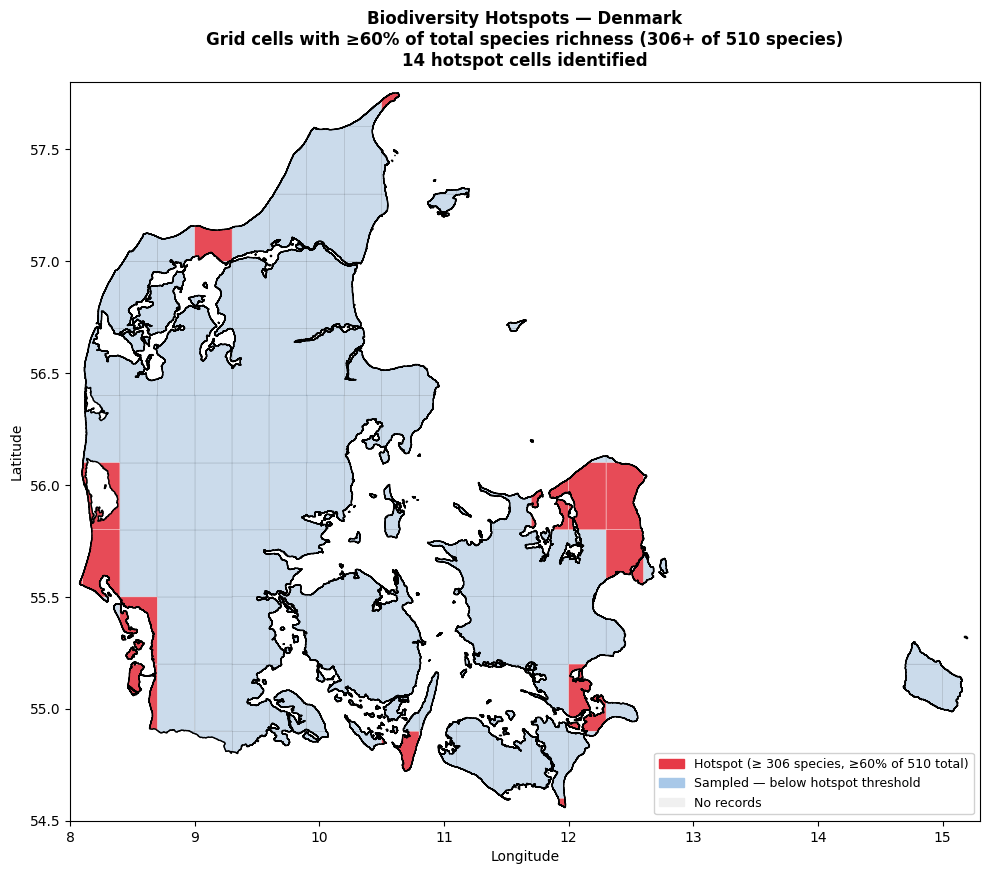

Saved to ../outputs/hotspots_60pct.png


In [ ]:
# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 12))

# Layer 1 — Denmark land background
denmark_outline.plot(
    ax=ax,
    color="#f0f0f0",
    edgecolor="black",
    linewidth=0.8
)

# Layer 2 — Non-hotspot cells with records (light blue, subtle)
# These give context — you can see where sampling happened
# without these dominating the visual
grid_richness[
    (grid_richness["species_richness"] > 0) &
    (~grid_richness["is_hotspot"])
].plot(
    ax=ax,
    color="#a8c8e8",    # muted blue — present but not the focus
    edgecolor="black",
    linewidth=0.1,
    alpha=0.5
)

# Layer 3 — Hotspot cells (bold red — the main finding)
grid_richness[grid_richness["is_hotspot"]].plot(
    ax=ax,
    color="#e63946",    # strong red — visually dominant
    edgecolor="white",
    linewidth=0.3,
    alpha=0.9
)

# Layer 4 — Denmark outline on top so border is always visible
denmark_outline.plot(
    ax=ax,
    color="none",
    edgecolor="black",
    linewidth=1.0
)

# ── Legend ────────────────────────────────────────────────────────────────────
legend_handles = [
    mpatches.Patch(
        color="#e63946",
        label=f"Hotspot (≥ {int(HOTSPOT_THRESHOLD)} species, "
              f"≥60% of {TOTAL_SPECIES} total)"
    ),
    mpatches.Patch(
        color="#a8c8e8",
        label="Sampled — below hotspot threshold"
    ),
    mpatches.Patch(
        color="#f0f0f0",
        edgecolor="black",
        label="No records"
    )
]

ax.legend(
    handles=legend_handles,
    loc="lower right",
    fontsize=9,
    framealpha=0.9
)

# ── Labels and formatting ─────────────────────────────────────────────────────
ax.set_title(
    f"Biodiversity Hotspots — Denmark\n"
    f"Grid cells with ≥60% of total species richness "
    f"({int(HOTSPOT_THRESHOLD)}+ of {TOTAL_SPECIES} species)\n"
    f"{grid_richness['is_hotspot'].sum()} hotspot cells identified",
    fontsize=12, fontweight="bold", pad=12
)

ax.set_xlabel("Longitude", fontsize=10)
ax.set_ylabel("Latitude",  fontsize=10)
ax.set_xlim(8.0,  15.3)
ax.set_ylim(54.5, 57.8)

plt.tight_layout()
plt.savefig("../outputs/hotspots_60pct.png", dpi=1600, bbox_inches="tight")
plt.show()

print("Saved to ../outputs/hotspots_60pct.png")

---
## National Parks Overlay
We add Denmark's **5 official national parks** to the hotspot map to visually compare 
whether protected areas coincide with high-richness cells.  
Park boundaries are approximated from official MFVM / SNS shapefiles 
(bounding-box polygons in WGS 84); replace with exact geometries for publication.

/var/folders/bq/wvw1r1955ld8nc25n3l95m8m0000gn/T/ipykernel_22303/445178257.py:59: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(


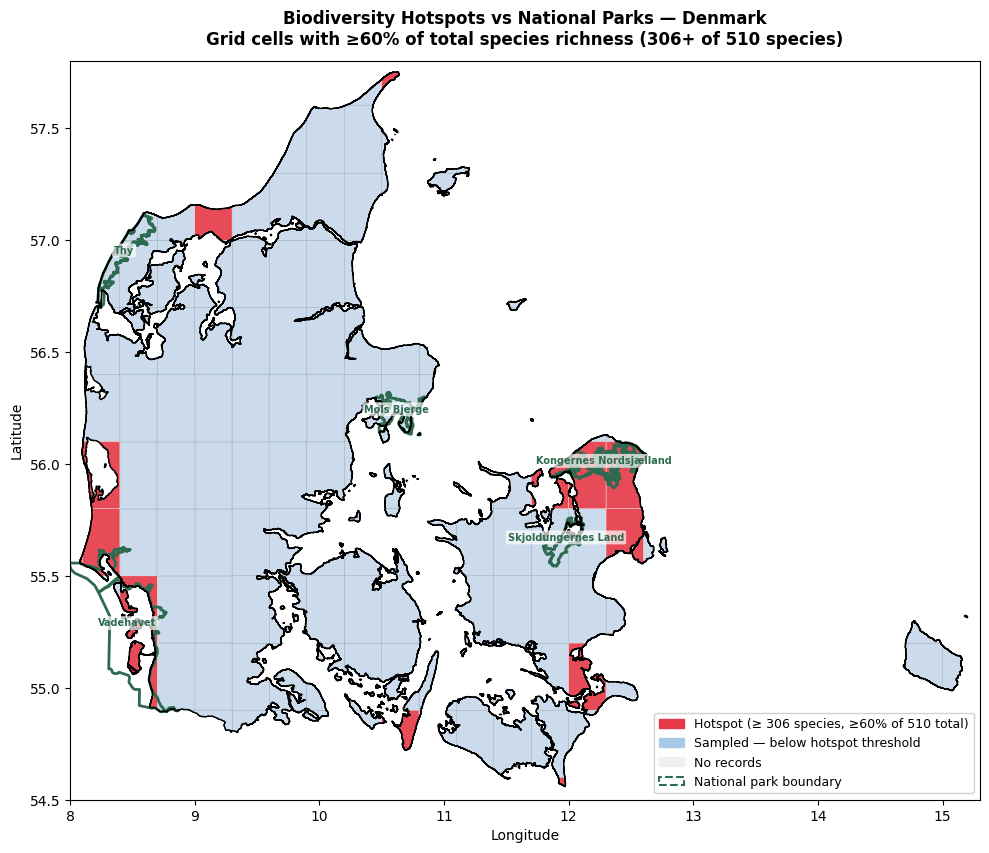

In [27]:
fig, ax = plt.subplots(figsize=(10, 12))

# Layer 1 — Denmark land background
denmark_outline.plot(ax=ax, color="#f0f0f0", edgecolor="black", linewidth=0.8)

# Layer 2 — Non-hotspot sampled cells (light blue)
grid_richness[
    (grid_richness["species_richness"] > 0) &
    (~grid_richness["is_hotspot"])
].plot(ax=ax, color="#a8c8e8", edgecolor="black", linewidth=0.1, alpha=0.5)

# Layer 3 — Hotspot cells (red)
grid_richness[grid_richness["is_hotspot"]].plot(
    ax=ax, color="#e63946", edgecolor="white", linewidth=0.3, alpha=0.9
)

# Layer 4 — National park polygons overlaid on top
# color="none" means transparent fill so the grid colours underneath show through
# This lets you visually see which hotspot cells fall inside a national park
national_parks.plot(
    ax=ax,
    color="none",
    edgecolor="#2d6a4f",    # dark green border — ecologically intuitive colour
    linewidth=2,
    linestyle="-"          # dashed so it is visually distinct from the Denmark outline
)

for _, row in national_parks.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(
        text=row["name"].replace("Nationalpark ", ""),  # shorten label
        xy=(centroid.x, centroid.y),
        fontsize=7,
        ha="center",
        color="#2d6a4f",
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.2",
            facecolor="white",
            alpha=0.7,
            edgecolor="none"
        )
    )

# Layer 5 — Denmark outline on top
denmark_outline.plot(ax=ax, color="none", edgecolor="black", linewidth=1.0)

# ── Legend ────────────────────────────────────────────────────────────────────
legend_handles = [
    mpatches.Patch(
        color="#e63946",
        label=f"Hotspot (≥ {int(HOTSPOT_THRESHOLD)} species, "
              f"≥60% of {TOTAL_SPECIES} total)"
    ),
    mpatches.Patch(
        color="#a8c8e8",
        label="Sampled — below hotspot threshold"
    ),
    mpatches.Patch(
        color="#f0f0f0",
        edgecolor="black",
        label="No records"
    ),
    mpatches.Patch(
        facecolor="none",
        edgecolor="#2d6a4f",
        linewidth=1.5,
        linestyle="--",
        label="National park boundary"
    )
]

ax.legend(handles=legend_handles, loc="lower right", fontsize=9, framealpha=0.9)

ax.set_title(
    f"Biodiversity Hotspots vs National Parks — Denmark\n"
    f"Grid cells with ≥60% of total species richness "
    f"({int(HOTSPOT_THRESHOLD)}+ of {TOTAL_SPECIES} species)",
    fontsize=12, fontweight="bold", pad=12
)

ax.set_xlabel("Longitude", fontsize=10)
ax.set_ylabel("Latitude",  fontsize=10)
ax.set_xlim(8.0,  15.3)
ax.set_ylim(54.5, 57.8)

plt.tight_layout()
plt.savefig("../outputs/hotspots_vs_national_parks.png", dpi=1600, bbox_inches="tight")
plt.show()

In [24]:
# ── Spatial join: which hotspot cells intersect a national park? ──────────────
hotspot_gdf = grid_richness[grid_richness["is_hotspot"]].copy()

# Do NOT replace geometry with centroid — we want the full polygon
# gpd.overlay with how="intersection" returns only the portions of
# hotspot cells that physically overlap with a park polygon.
# Any hotspot cell that touches or overlaps a park appears in the result.

intersected = gpd.overlay(
    hotspot_gdf,
    national_parks[["name", "geometry"]],
    how="intersection",
    keep_geom_type=False
)

# A hotspot cell may intersect multiple parks — get unique cell IDs that matched
matched_cell_ids   = intersected["grid_cell_id"].unique()
inside_park        = hotspot_gdf[hotspot_gdf["grid_cell_id"].isin(matched_cell_ids)]
outside_park       = hotspot_gdf[~hotspot_gdf["grid_cell_id"].isin(matched_cell_ids)]

print("=" * 52)
print("Hotspot ↔ National Park overlap summary")
print("=" * 52)
print(f"Total hotspot cells          : {len(hotspot_gdf)}")
print(f"  Intersecting a national park  : {len(inside_park)}  "
      f"({100*len(inside_park)/len(hotspot_gdf):.1f} %)")
print(f"  Outside all national parks    : {len(outside_park)}  "
      f"({100*len(outside_park)/len(hotspot_gdf):.1f} %)")
print()
print("Hotspot cells per park:")
print(intersected.groupby("name")["species_richness"]
      .agg(["count", "min", "max", "mean"])
      .rename(columns={"count": "cells", "min": "min_sp",
                       "max": "max_sp",  "mean": "avg_sp"})
      .round(1)
      .to_string())
print()
print("Interpretation hints:")
print("  • Parks with many hotspot cells → protection aligns with biodiversity peaks.")
print("  • Hotspots outside all parks   → potential gaps in the protected-area network.")
print("  • Parks with zero hotspot cells → lower richness or sampling bias in that region.")

Hotspot ↔ National Park overlap summary
Total hotspot cells          : 14
  Intersecting a national park  : 7  (50.0 %)
  Outside all national parks    : 7  (50.0 %)

Hotspot cells per park:
                                     cells  min_sp  max_sp  avg_sp
name                                                              
Nationalpark Kongernes Nordsjælland      3     313     337   321.7
Nationalpark Vadehavet                   4     323     360   339.0

Interpretation hints:
  • Parks with many hotspot cells → protection aligns with biodiversity peaks.
  • Hotspots outside all parks   → potential gaps in the protected-area network.
  • Parks with zero hotspot cells → lower richness or sampling bias in that region.
